# Question 1: Problem description and formulation

### 1.1 Context
- The venue has 5 tables available, and each table seats 6 people
- There are 07 teams with 29 employees from different departments

Our goal is to find the optimal seating arrangement that minimizes the number of split teams.

### 1.2 Mathematical Formulation

#### 1.2a Decision Variables

First, let's look at binary variables

$$
y_i =
\begin{cases}
1, & \text{if team }i\text{ is splitted},\\
0, & \text{otherwise}
\end{cases}
$$



$$
t_{i,j} =
\begin{cases}
1, & \text{if team }i\text{ is splitted to table j},\\
0, & \text{otherwise}
\end{cases}
$$

- $y_{j}$ allows us to count how many teams are split

- $t_{i,j}$ ​indicates whether team $i$ uses table $j$

Also another integer decision variable is introduced

- $x_{i,j} \in \mathbb{Z}_{\ge 0}$: number of members of team i seated table j (integer variables)


#### 1.2b Mathematical model

Let denote:

- $T_{i}$ being number of members in team $i$

- $c_{j}$ seating capacity of table $j$

The objective is to minimise the number of split teams:

$$
\min \sum_{i \in \mathcal{I}} y_i
$$

Subject to the following constraints: 

1. All team members must be seated
$$
\sum_{j \in \mathcal{J}} x_{ij} = T_{i},
\quad \forall i \in \mathcal{I}.
$$

2. Total employees in each table need to less or equal to table capacity
   $$
   \sum_{i \in \mathcal{I}} x_{ij} \le c_{j} \qquad \forall j \in \mathcal{J}
   $$
3.  Teams should not be split between more than 2 tables
   $$
   \sum_{j \in \mathcal{J}} t_{ij} \le 2 \qquad \forall i \in \mathcal{I}
   $$

4. If team i is assigned to more than 1 table, then $y_{i}$ = 1
$$
y_i \ge \sum_{j \in \mathcal{J}} t_{ij} - 1 \qquad \forall i \in \mathcal{I}
$$

5. If team i is assigned to table j, then number of members from team i at table j cannot exceed the team size
$$
x_{ij} \le T_i \, t_{ij} \qquad \forall i,j
$$

# Key Functions - for Q2,3,4,5

To support reuse, maintenance, and systematic experimentation across different scenarios (Q2–Q5), several key functions are defined and implemented. The modelling process follows these steps:

1. **Model initialisation**: function `build_core_model` is used to create an create an Xpress problem named `seatAllocation`, define parameters and define decision variables.

2. **Parameter definition**: The fixed input data of the problem are defined as follows:
- `numTeams`: The set of teams $I$
- `numTables`: The set of tables $J$
- $T_{i}$: Size for each team $i$
- `tableCapacity`: Table capacity for each table $c_{j}$. By default, `tableCapacity` has capacity 6 for each table. Howerver, this parameter can be modified to reflect changes in available seating (Q4).

3. **Decision variables**: Function `define_decision_variables` to help define decision variables including $x_{ij}$, $y_{i}$, $t_{ij}$ which are introduced in the previous section.

4. **Objective function**: The objective is to minimise the number of split teams. 
- Without team priorities, the objective function is implemented in function `set_objective_min_split` as: $\min \sum_{i \in \mathcal{I}} y_i$

- With team priorities, weighted penalties $w_i$ are introduced to reflect the relative importance of teams that should not be split. Therefore, the objective becomes: $\min \sum_{i \in \mathcal{I}} w_i y_i$, which is implemented in function `set_objective_priority`


5. **Constraints**: Function `add_core_constraints` defines five core constraints derived from the problem description. In addition, if splitting teams into single individuals is not allowed, an additional constraint is introduced to prevent teams to be split into single members.

6. **Solution and analysis**: The functions `solve_model`, `show_result`, and `visualise_optimal_seating` are used to solve the optimisation model and analyse the resulting seating arrangements.

In [23]:
import xpress as xp # optimisation solver
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings 
import sys # check python version
warnings.filterwarnings('ignore')

print("Python version:", sys.version)
print("Xpress version:", xp.__version__)
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Python version: 3.12.12 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 20:07:49) [Clang 20.1.8 ]
Xpress version: 9.8.0
Pandas version: 2.3.3
NumPy version: 2.3.5


In [24]:
# ============================================================
# Function for core model
# ============================================================
def build_core_model(tableCapacity, teams):
    # create optimization problem
    p = xp.problem(name = "seatAllocation")
    
    # define parameters
    numTeams = range(len(teams)) # number of teams
    numTables = range(len(tableCapacity)) # number of tables
    T = [len(members) for members in teams.values()] # members in each team
    
    # define decision variables
    y, x, t = define_decision_variables(p, numTeams, numTables)
    
    return p, numTeams, numTables, x, y, t, T
  
  
# ============================================================
# Function for Decision variables
# ============================================================
def define_decision_variables(p, numTeams, numTables):

    # y[i] = 1 if team i is splitted into different tables, 0 otherwise
    y = p.addVariables(numTeams, vartype = xp.binary, name = "y")
    # x[i][j]: number of members from team i assigned to table j
    x = p.addVariables(numTeams, numTables, vartype = xp.integer, lb = 0, name = "x")
    # t[i][j] = 1 if team i is assigned to table j, 0 otherwise
    t = p.addVariables(numTeams, numTables, vartype = xp.binary, name = "t")
    
    return y,x,t 

# ============================================================
# Function for Objective: minimizes the number of split teams
# ============================================================
def set_objective_min_split(p, y, numTeams):
    #  minimizes the number of split teams
    obj = xp.Sum(y[i] for i in numTeams)
    p.setObjective(obj, sense=xp.minimize)


# ============================================================
# Function for core constraints
# ============================================================
def add_core_constraints(p, numTeams, numTables, x, y, t, T, tableCapacity):
    
    # Constraint 1: all team members must be seated
    p.addConstraint(xp.Sum(x[i, j] for j in numTables) == T[i] for i in numTeams)

    # Constraint 2: numbers in each table cannot exceed table capacity
    p.addConstraint(xp.Sum(x[i,j] for i in numTeams) <= tableCapacity[j] for j in numTables)

    # Constraint 3: a team should not be split between more than 2 tables
    p.addConstraint(xp.Sum(t[i,j] for j in numTables) <= 2 for i in numTeams)

    # Constraint 4: link y and t variables: if team i is assigned to more than 1 table, then y[i] = 1
    p.addConstraint(y[i] >= xp.Sum(t[i,j] for j in numTables) - 1  for i in numTeams) 
    
    # Constraint 5: if team i is assigned to table j, then number of members from team i at table j cannot exceed the team size
    p.addConstraint((x[i, j] <= T[i] * t[i,j] for i in numTeams) for j in numTables)



# ============================================================
# Function for returning outputs
# ============================================================
def solve_model(p, numTeams, numTables, x, y):
    # solve model
    p.controls.outputlog = 0
    p.optimize()
    # model outputs
    out = {
        "numTeams": numTeams,
        "numTables": numTables,
        "status": p.attributes.solstatus,
        "objective": None,
        "sol_x": None,
        "sol_y": None
    }

    if out["status"] == xp.SolStatus.OPTIMAL:
        out["sol_x"] = p.getSolution(x)
        out["sol_y"] = p.getSolution(y)
        out["objective"] = p.getObjVal()

    return out

# ============================================================
# Function for summarizing and displaying results
# ============================================================
def show_result(optimization_output):
    if optimization_output['status'] == xp.SolStatus.OPTIMAL:
        print("Optimal solution found")
        # objective value
        print("Objective Min Z =", optimization_output['objective'])
    elif optimization_output['status'] == xp.SolStatus.INFEASIBLE:
        print("Model is infeasible")
    elif optimization_output['status'] == xp.SolStatus.UNBOUNDED:
        print("Model is unbounded")
    else:
        print("No solution, status =", optimization_output['status'])

    print(f"Total number of splitted teams: {sum(optimization_output['sol_y'][i] for i in optimization_output['sol_y'])}\n")
    
    for i in optimization_output['numTeams']:
        seats = {j: optimization_output['sol_x'][(i, j)] for j in optimization_output['numTables'] if optimization_output['sol_x'][(i, j)] > 0.5}

        if seats:
            parts = []
            for j, v in seats.items():
                parts.append(f"table {j+1} ({int(round(v))} members)")

            seating_str = ", ".join(parts)
            print(f"Team {i+1}: sitting at {seating_str}")
        
    

In [25]:
# ============================================================
# Function for visualising results
# ============================================================

def visualise_optimal_seating(input, tableCapacity, nonsplit_color="#cfe8ff", split_color="#F79F3B"):
    """Visualise the optimal seating arrangement as a stacked bar chart. If team is split, use orange color; otherwise, use blue
    """
    teams = list(input["numTeams"])
    tables = list(input["numTables"])

    # Determine split teams: split if assigned to >=2 tables with >0.5 members
    split_team = {}
    for i in teams:
        used_tables = [j for j in tables if input["sol_x"].get((i, j), 0) > 0.5]
        split_team[i] = (len(used_tables) >= 2)

    # Build df: rows=tables, cols=teams
    df = pd.DataFrame(
        0,
        index=[f"Table {j+1}" for j in tables],
        columns=[f"Team {i+1}" for i in teams],
        dtype=int
    )

    for i in teams:
        for j in tables:
            v = input["sol_x"].get((i, j), 0)
            if v > 0.5:
                df.loc[f"Table {j+1}", f"Team {i+1}"] = int(round(v))

    # Colors: assign colors based on split status
    team_colors = {
        f"Team {i+1}": (split_color if split_team[i] else nonsplit_color)
        for i in teams
    }

    # Plot stacked bars with gray borders
    fig, ax = plt.subplots(figsize=(10, 6))
    bottom = np.zeros(len(df.index))

    # plot bars
    for team in df.columns:
        ax.bar(
            df.index,
            df[team].values,
            bottom=bottom,
            label=team,
            color= team_colors[team],
            edgecolor="#8A8A8A",
            linewidth= 1
        )
        bottom += df[team].values

    # add capacity line
    x = np.arange(len(df.index))
    ax.step(
        x, tableCapacity, where="mid",
        linestyle="--", color="red", linewidth=2, label="Table capacity"
    )
    
    # styling
    ax.legend(title="Team", bbox_to_anchor=(1.05, 1), loc="upper left")
    ax.set_xlabel("Table")
    ax.set_ylabel("Number of team members")
    ax.set_title("Members per table (stacked by team)")
    ax.set_ylim(0, max(tableCapacity) + 2)

    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


# Question 2

As requirement, we define `teams` and `tableCapacity` as following:

In [26]:
teams = {
    1: ["Rachel", "Marah", "Sam"],
    2: ["Andrew", "Daisy", "Ben", "Abby"],
    3: ["Briony", "Henry"],
    4: ["Emma", "Edward", "Arun", "Will", "Lilly"],
    5: ["Steve", "Lucy", "Lewis", "Harry", "Emily", "Katie"],
    6: ["Lisa", "Jessica", "Rhiannon", "Jake"],
    7: ["Sophie", "Claire", "Nick", "Terry", "Amy"]
}

tableCapacity = [6,6,6,6,6]


In [27]:
def allocate_seats_core(tableCapacity, teams):
    """Allocate seats to teams while minimizing the number of split teams.
    """
    # define model, parameters, decision variables
    p, numTeams, numTables, x, y, t, T = build_core_model(tableCapacity, teams)
    
    # define objective
    set_objective_min_split(p, y, numTeams)
    
    # core constraints
    add_core_constraints(p, numTeams, numTables, x, y, t, T, tableCapacity)
    # return solution
    output = solve_model(p, numTeams, numTables, x, y)
    
    return output

In [28]:
# core constraints implemented in the function
q2 = allocate_seats_core(tableCapacity = tableCapacity, teams = teams)
show_result(q2)

Optimal solution found
Objective Min Z = 1.0
Total number of splitted teams: 1.0

Team 1: sitting at table 4 (1 members), table 5 (2 members)
Team 2: sitting at table 5 (4 members)
Team 3: sitting at table 2 (2 members)
Team 4: sitting at table 4 (5 members)
Team 5: sitting at table 3 (6 members)
Team 6: sitting at table 2 (4 members)
Team 7: sitting at table 1 (5 members)


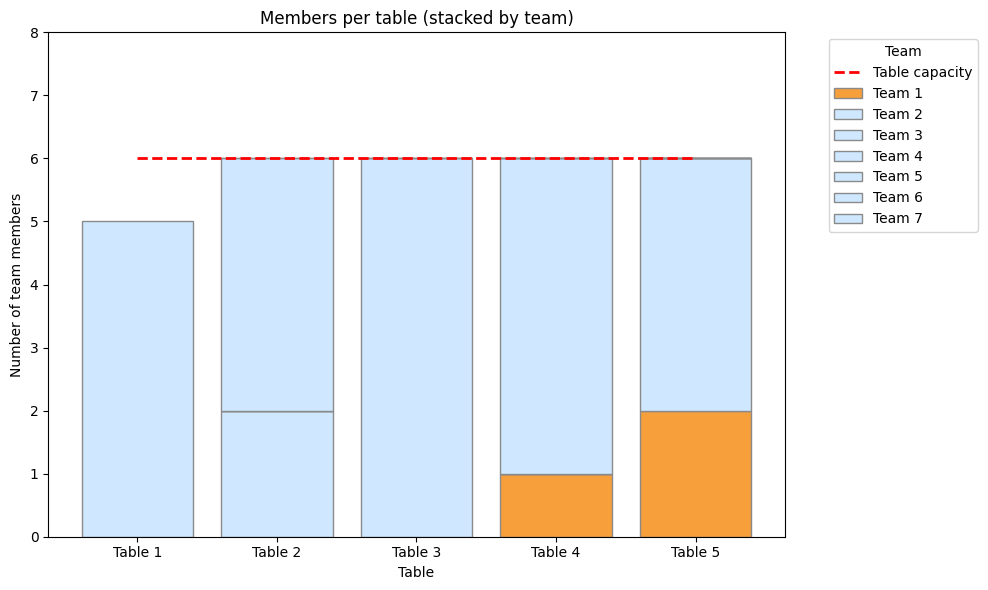

In [29]:
visualise_optimal_seating(q2, tableCapacity=tableCapacity )

Based on the result, team 1 is split across 2 tables, as indicated by the orange colour, with **1 member** assigned to table 4 and **2 members** assigned to table 5. Except for table 1, which has unused capacity, all other tables operate at full capacity.

# Question 3

In Q2, there is one person to be separated from the rest of their team.

Therefore, A new constraint is added to the model to avoid splitting into single members: if a team is assigned to a table, there should be at least 2 members sitting together in that table.
$$
x_{ij} \ge 2 t_{ij} \qquad \forall i,j
$$

In [30]:
def allocate_seats_not_allow_split(teams, tableCapacity):
    
    # design model
    p, numTeams, numTables, x, y, t, T = build_core_model(tableCapacity, teams)

    # define objective
    set_objective_min_split(p, y, numTeams)

    # core constraints
    add_core_constraints(p, numTeams, numTables, x, y, t, T, tableCapacity)
    # ============================================================
    # NEW-constraint 6: teams cannot be split into single individuals
    # ============================================================
    p.addConstraint(x[i,j] >= 2 * t[i,j] for i in numTeams for j in numTables)

    # return solution
    output = solve_model(p, numTeams, numTables, x, y)
    
    return output

In [31]:
# do not allow splitting single individuals
q3 = allocate_seats_not_allow_split(teams = teams, tableCapacity = tableCapacity)
show_result(q3)

Optimal solution found
Objective Min Z = 1.0
Total number of splitted teams: 1.0

Team 1: sitting at table 1 (3 members)
Team 2: sitting at table 3 (4 members)
Team 3: sitting at table 5 (2 members)
Team 4: sitting at table 1 (3 members), table 3 (2 members)
Team 5: sitting at table 4 (6 members)
Team 6: sitting at table 5 (4 members)
Team 7: sitting at table 2 (5 members)


After running the model, single-member splits are no longer allowed. The optimal solution indicates that only team 4 is split into table 1 (3 members) and table 3 (2 members), satisfying all model constraints. In this solution, all tables except Table 2 operate at full capacity.

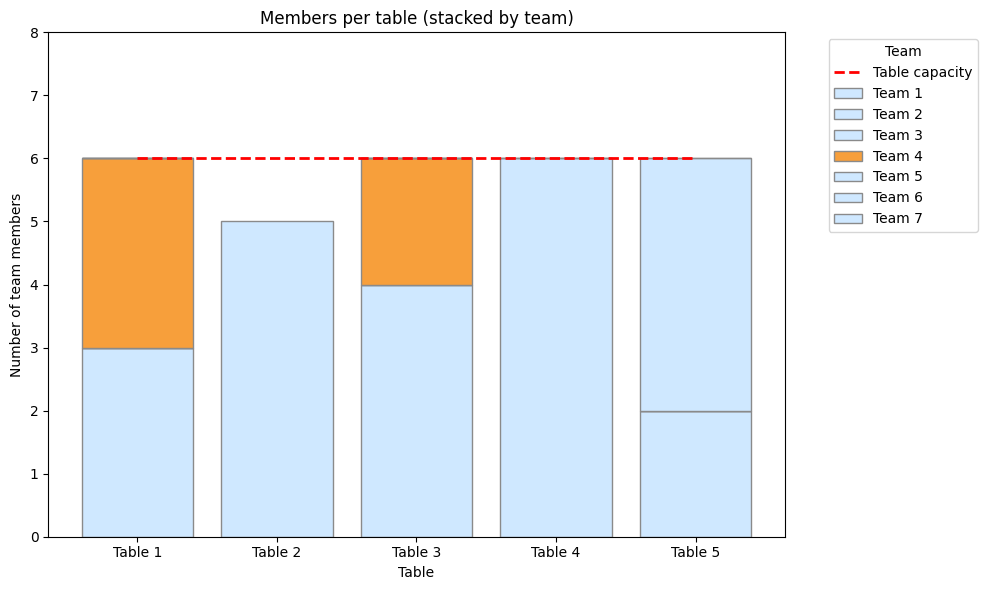

In [32]:
visualise_optimal_seating(q3, tableCapacity=tableCapacity )

# Question 4

The day before the event, one of the tables breaks. There aren’t any spares and instead the coordinator
replaces it with 2 tables, one of which seats 4 and the other seats 2 (for a total of 6 tables). To reflect this change, the table capacity parameter is updated accordingly. In addition, teams are required to be seated in groups of at least two members

Assume that table 5 is broken and it is replaced with 2 other tables (4 seats and 2 seats). The updated table capacities are: `tableCapacity = [6,6,6,6,4,2] `

In [33]:
# case where table 5 has only 4 seats and table 6 has only 2 seats
new_tableCapacity = [6,6,6,6,4,2] 
q4 = allocate_seats_not_allow_split(teams = teams, tableCapacity = new_tableCapacity)
show_result(q4)

Optimal solution found
Objective Min Z = 1.0
Total number of splitted teams: 1.0

Team 1: sitting at table 3 (3 members)
Team 2: sitting at table 1 (4 members)
Team 3: sitting at table 1 (2 members)
Team 4: sitting at table 3 (3 members), table 6 (2 members)
Team 5: sitting at table 4 (6 members)
Team 6: sitting at table 5 (4 members)
Team 7: sitting at table 2 (5 members)


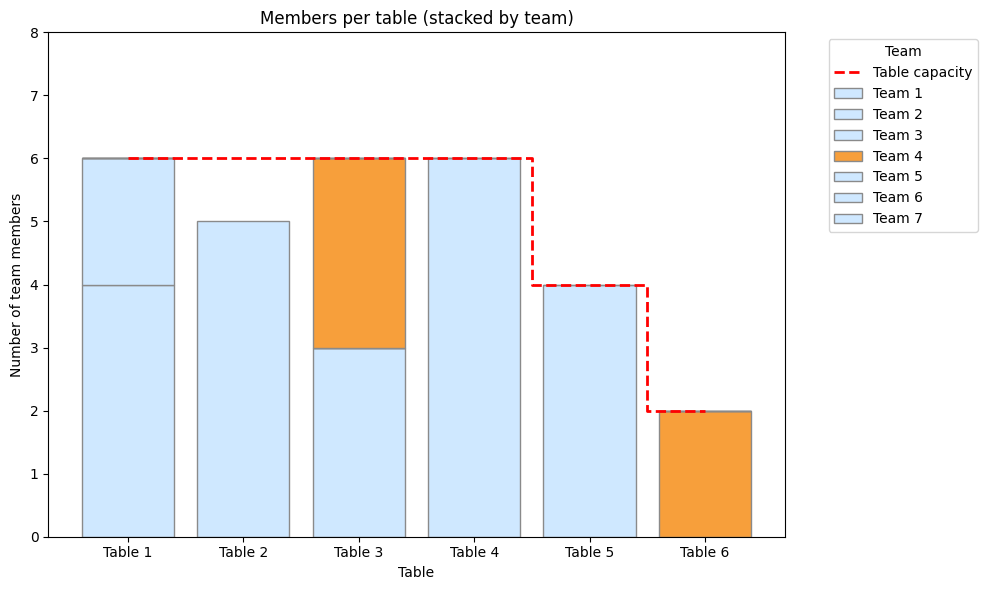

In [34]:
visualise_optimal_seating(q4, tableCapacity = new_tableCapacity)

After re-solving the model, an optimal solution indicates that team 4 is split across two tables, with 3 members assigned to table 3 and 2 members assigned to table 6. 

This optimal solution respects both the updated table capacities *(4 members in table 5 and 2 members in table 6)* and the constraint that teams cannot be split into single individuals. All other teams are seated at a single table.

# Question 5

Because some teams should not be split with high priority over others, the objective function is updated accordingly:
$$\min \sum_{i \in \mathcal{I}} w_i y_i$$

weighted penalties $w_i$ are introduced to assign priorities to teams

In [35]:
def set_objective_priority(p, y, numTeams, priority_weight):
    # higher numbers mean higher priority
    obj = xp.Sum(y[i]* priority_weight[i] for i in numTeams) 
    p.setObjective(obj, sense=xp.minimize)
    
    
def allocate_seats_priority(teams, tableCapacity, priority_weight):
    
    # design model
    p, numTeams, numTables, x, y, t, T = build_core_model(tableCapacity, teams)

    # ============================================================
    # New objective function
    # ============================================================
    set_objective_priority(p, y, numTeams, priority_weight)

    #  constraints
    add_core_constraints(p, numTeams, numTables, x, y, t, T, tableCapacity)
    # constraint 6: teams connot be split into single individuals
    p.addConstraint(x[i,j] >= 2 * t[i,j] for i in numTeams for j in numTables)

    # return solution
    output = solve_model(p, numTeams, numTables, x, y)
    
    return output

# there are 6 tables with capacities as below
new_tableCapacity = [6,6,6,6,4,2]

Optimal solution found
Objective Min Z = 1.0
Total number of splitted teams: 1.0

Team 1: sitting at table 2 (3 members)
Team 2: sitting at table 1 (4 members)
Team 3: sitting at table 1 (2 members)
Team 4: sitting at table 3 (5 members)
Team 5: sitting at table 4 (6 members)
Team 6: sitting at table 5 (4 members)
Team 7: sitting at table 2 (3 members), table 6 (2 members)


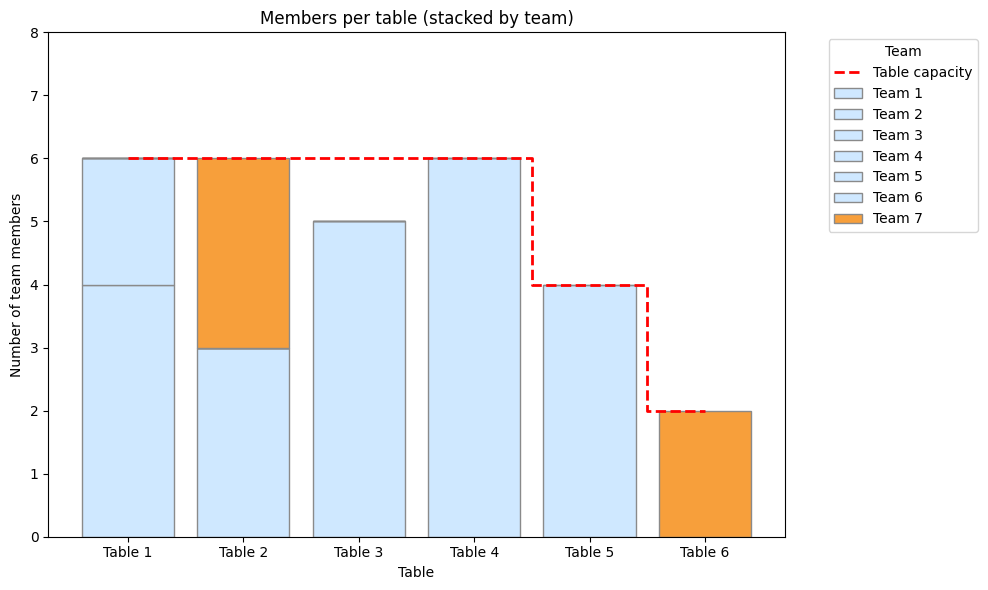

In [36]:
# assume that team 4 has the highest priority not to be split 
q5 = allocate_seats_priority(teams = teams, tableCapacity = new_tableCapacity, priority_weight= [1, 1, 1, 10, 1, 1, 1])
show_result(q5)
visualise_optimal_seating(q5, tableCapacity=new_tableCapacity )

Team 4 cannot be split, so team 7 is split in this case

Optimal solution found
Objective Min Z = 1.0
Total number of splitted teams: 1.0

Team 1: sitting at table 3 (3 members)
Team 2: sitting at table 1 (4 members)
Team 3: sitting at table 1 (2 members)
Team 4: sitting at table 3 (3 members), table 6 (2 members)
Team 5: sitting at table 4 (6 members)
Team 6: sitting at table 5 (4 members)
Team 7: sitting at table 2 (5 members)


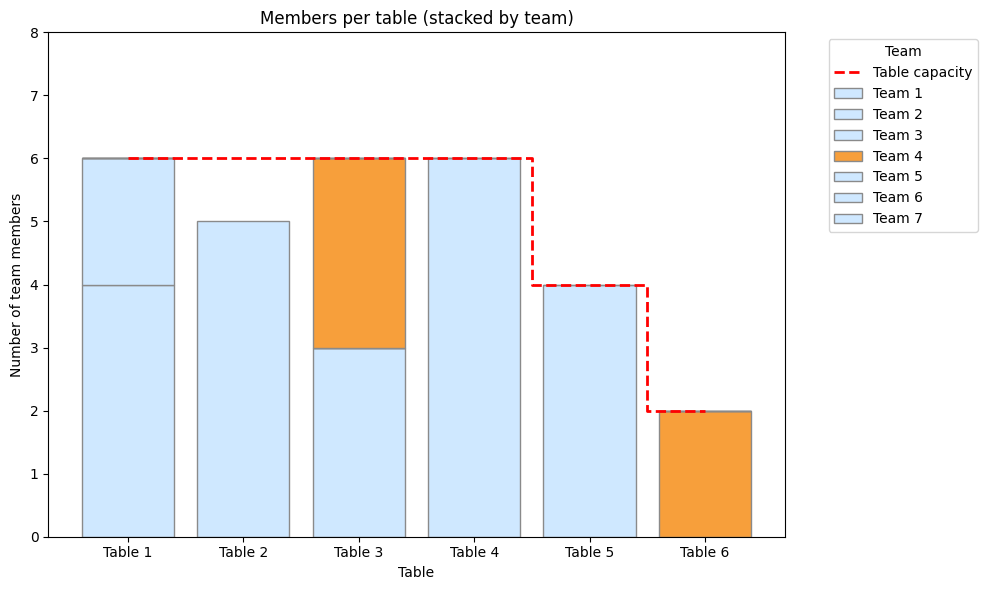

In [37]:
# assume that team 7 has the highest priority not to be split 
q5 = allocate_seats_priority(teams = teams, tableCapacity = new_tableCapacity, priority_weight= [1, 1, 1, 1, 1, 1, 10])
show_result(q5)
visualise_optimal_seating(q5, tableCapacity=new_tableCapacity )

Team 7 cannot be split, team 4 is split in this case